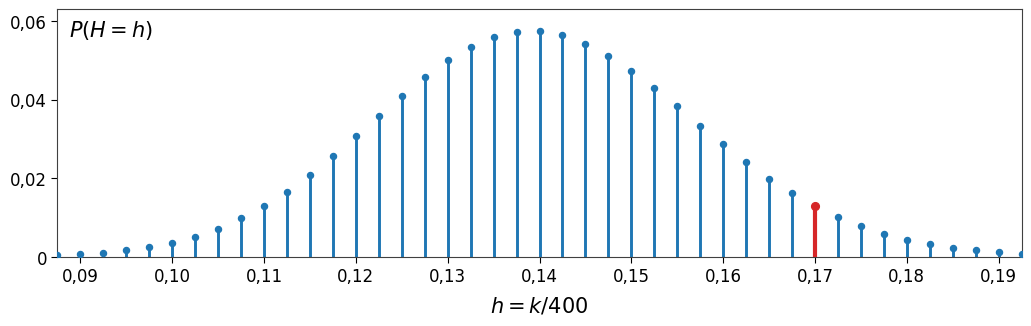

In [5]:
from dataclasses import dataclass
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
from scipy.stats import binom


plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})


@dataclass(frozen=True)
class Konfiguration:
    n: int = 400
    p: float = 0.14
    h_markiert: float = 0.17
    x_min: float = 0.0875
    x_max: float = 0.1925
    y_max: float = 0.063
    ausgabename: str = "Binomialverteilung_H"


def berechne_verteilung(konfiguration: Konfiguration):
    k = np.arange(konfiguration.n + 1)
    h = k / konfiguration.n
    wahrscheinlichkeiten = binom.pmf(k, konfiguration.n, konfiguration.p)

    sichtbar = (h >= konfiguration.x_min) & (h <= konfiguration.x_max)
    return k[sichtbar], h[sichtbar], wahrscheinlichkeiten[sichtbar]


def formatiere_dezimalzahl(wert: float, _position: int) -> str:
    if np.isclose(wert, 0):
        return "0"
    return f"{wert:.2f}".replace(".", ",")


def zeichne_verteilung(konfiguration: Konfiguration):
    k, h, wahrscheinlichkeiten = berechne_verteilung(konfiguration)
    k_markiert = round(konfiguration.n * konfiguration.h_markiert)
    if not np.isclose(k_markiert / konfiguration.n, konfiguration.h_markiert):
        raise ValueError("Der markierte Wert ist für diesen Stichprobenumfang nicht möglich.")
    markiert = k == k_markiert

    fig, ax = plt.subplots(figsize=(10.2, 3.15), constrained_layout=True)

    ax.vlines(
        h[~markiert],
        0,
        wahrscheinlichkeiten[~markiert],
        color="tab:blue",
        linewidth=2.1,
        zorder=2,
    )
    ax.scatter(
        h[~markiert],
        wahrscheinlichkeiten[~markiert],
        color="tab:blue",
        s=19,
        zorder=3,
    )

    ax.vlines(
        h[markiert],
        0,
        wahrscheinlichkeiten[markiert],
        color="tab:red",
        linewidth=3.0,
        zorder=4,
    )
    ax.scatter(
        h[markiert],
        wahrscheinlichkeiten[markiert],
        color="tab:red",
        s=31,
        zorder=5,
    )

    ax.set_xlim(konfiguration.x_min, konfiguration.x_max)
    ax.set_ylim(0, konfiguration.y_max)
    ax.set_xticks(np.arange(0.09, 0.191, 0.01))
    ax.set_yticks([0, 0.02, 0.04, 0.06])
    ax.xaxis.set_major_formatter(FuncFormatter(formatiere_dezimalzahl))
    ax.yaxis.set_major_formatter(FuncFormatter(formatiere_dezimalzahl))

    ax.set_xlabel(
        rf"$h=k/{konfiguration.n}$",
        fontsize=15,
        labelpad=7,
    )
    ax.text(
        0.012,
        0.965,
        r"$P(H=h)$",
        transform=ax.transAxes,
        fontsize=15,
        ha="left",
        va="top",
    )

    ax.tick_params(axis="both", labelsize=12, length=4, width=0.8)
    for rahmen in ax.spines.values():
        rahmen.set_color("0.25")
        rahmen.set_linewidth(0.8)

    plt.show()
    #fig.savefig(f"{konfiguration.ausgabename}.pdf", bbox_inches="tight", pad_inches=0.02)
   # fig.savefig(
    #    f"{konfiguration.ausgabename}.png",
    #    dpi=300,
    #    bbox_inches="tight",
    #    pad_inches=0.02,
     #   facecolor="white",
   # )
    return fig


def main():
    konfiguration = Konfiguration()
    zeichne_verteilung(konfiguration)
    plt.close()


if __name__ == "__main__":
    main()